In [16]:
import pandas as pd
import seaborn as sns


In [17]:
#Importing the enriched reviews table
reviews = pd.read_csv('enriched_amazon_reviews.csv')

### How do different product issues impact customer retention (Repurchase Intent)?
**Objective:**

Not all customer complaints are equal. A customer might complain about a high price but still buy the product again. However, if they receive spoiled food, they will probably never return.

In this section, we want to see which specific problems (```Issue_Category```) actually drive customers away for good (```Repurchase_Intent```). By looking at these two columns side-by-side, we can identify the most damaging issues and understand what the business needs to fix first.

In [18]:
rates_crosstab = pd.crosstab(reviews['Issue_Category'], reviews['Repurchase_Intent'])
print(rates_crosstab)

Repurchase_Intent  No  Unclear  Yes
Issue_Category                     
Bad_Taste          24        5    4
Other_Issue        16        9    4
Packaging_Issue     1        3    2
Price_Complaint     2        5    9
Stale_Expired       1        0    1


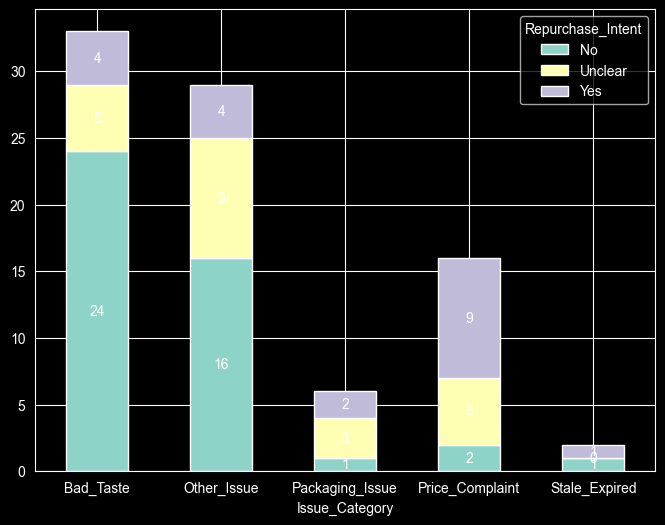

In [19]:
ax = rates_crosstab.plot.bar(stacked=True, rot = 0, figsize=(8,6))
#Adding a numeric label to each container
for container in ax.containers:
    ax.bar_label(container=container, label_type='center')

**Key Takeaway:** [To be updated based on full dataset run]

### Which product issues trigger the most negative emotions?

**Objective:**
There is a big difference between a customer simply stating a fact ("this is too expensive") and a customer leaving a frustrated or sarcastic review. Highly emotional and angry reviews can easily damage a brand's reputation online.

In this section, we want to find out which specific problems (`Issue_Category`) cause the highest levels of frustration and sarcasm (`Emotional_Tone`). By crossing these two columns, we can pinpoint exactly which defects turn mildly disappointed buyers into actively angry customers.

In [20]:
emotion_crosstab = pd.crosstab(reviews['Issue_Category'], reviews['Emotional_Tone'])
print(emotion_crosstab)

Emotional_Tone   Disappointment  Frustration  Sarcasm
Issue_Category                                       
Bad_Taste                    26            2        2
Other_Issue                  17            8        0
Packaging_Issue               4            1        0
Price_Complaint               5            4        0
Stale_Expired                 1            1        0


<Axes: xlabel='Emotional_Tone', ylabel='Issue_Category'>

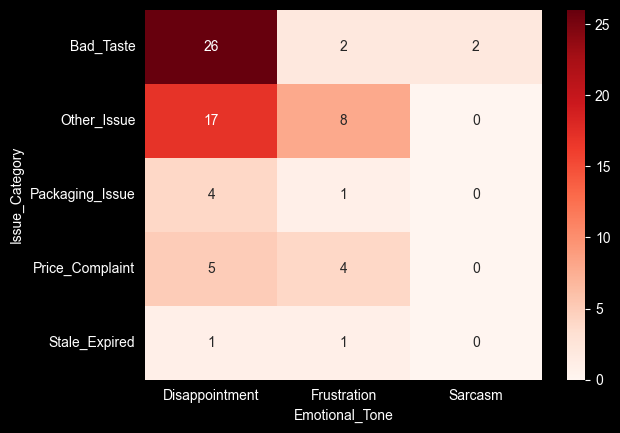

In [21]:
sns.heatmap(emotion_crosstab, annot=True, cmap='Reds')

**Key Takeaway:** [To be updated based on full dataset run]

### At what rating do we actually lose the customer?

**Objective:**
It is obvious that 1-star reviews lead to lost customers and 5-star reviews lead to retention. However, the business risk usually hides in the grey area, specifically the 2-star and 3-star ratings.

Are 3-star customers politely forgiving, or have they already decided not to come back? By mapping the numerical `Score` against `Repurchase_Intent`, we can discover the true rating at which a customer decides to never return. This helps the business understand if a so-called "average" rating is actually a failing grade.

In [22]:
score_repurchase_crosstab = pd.crosstab(reviews['Score'], reviews['Repurchase_Intent'])
print(score_repurchase_crosstab)

Repurchase_Intent  No  Unclear  Yes
Score                              
1                  23        5    0
2                   7        1    1
3                  12       11    1
4                   2        5   24
5                   0        4  151


<Axes: xlabel='Score'>

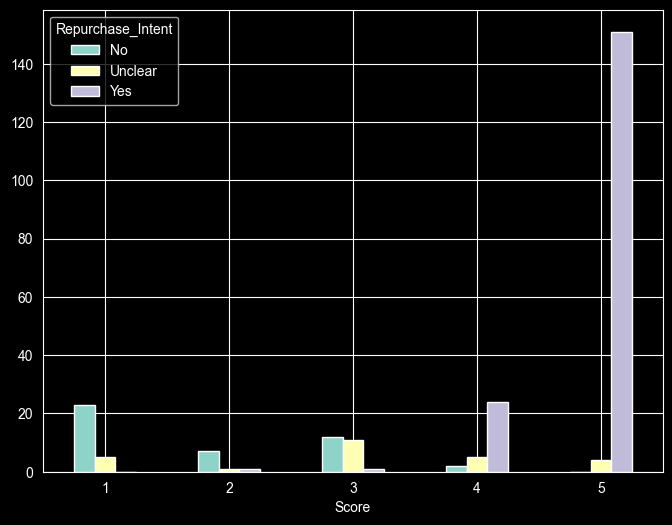

In [23]:
score_repurchase_crosstab.plot.bar(rot=0, figsize=(8, 6))

**Key Takeaway:** [To be updated based on full dataset run]